In [41]:
# Import necessary libraries for data processing, neural networks, and visualization
import random
import numpy as np
from PIL import Image
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

# Import PyTorch utilities for datasets and image transformations
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler, SubsetRandomSampler
from torchvision.transforms import Compose, ToTensor, Normalize, ToPILImage, RandomHorizontalFlip, Resize

# Install and import torchsummary for model architecture visualization
!pip install torchsummary
from torchsummary import summary

import matplotlib.pyplot as plt
%matplotlib inline

# Detect if GPU (CUDA) is available; otherwise, use CPU
device = ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Define our network class

In [42]:
# Define a shallow neural network for image classification
class ShallowNN4Images(nn.Module):
    def __init__(self, input_num, hidden_num, output_num):
        super(ShallowNN4Images, self).__init__()
        # Flatten the input 2D image into a 1D vector
        self.flatten = nn.Flatten()
        hidden_num2 = int(hidden_num / 2)
        # Define linear (fully connected) layers
        self.hidden1 = nn.Linear(input_num, hidden_num)
        self.hidden2 = nn.Linear(hidden_num, hidden_num2)
        self.output = nn.Linear(hidden_num2, output_num)
        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass input through the layers with ReLU activation
        x = self.flatten(x)
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        out = self.output(x)
        return out

# Initialize model hyperparameters
input_num = 784  # 28x28 pixels
hidden_num = 64
output_num = 10 # 10 classes in FashionMNIST

# Instantiate the model and move it to the detected device
model = ShallowNN4Images(input_num, hidden_num, output_num)
model.to(device)

# Print the model architecture summary
print(summary(model, (1, 28, 28)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 64]          50,240
              ReLU-3                   [-1, 64]               0
            Linear-4                   [-1, 32]           2,080
              ReLU-5                   [-1, 32]               0
            Linear-6                   [-1, 10]             330
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.20
Estimated Total Size (MB): 0.21
----------------------------------------------------------------
None


### Define the Loss function

In [43]:
# Define loss functions for different types of classification tasks

# Binary Cross Entropy with Logits (includes sigmoid internally)
criterion_binary_case = torch.nn.BCEWithLogitsLoss()

# Multi-class Cross Entropy (includes softmax internally)
criterion_multi_class = torch.nn.CrossEntropyLoss()

### Define your train val test dataset
#### Option 1: dataset is a part of pytorch


In [44]:
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Define data transformations: convert to tensor and normalize pixels to range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the FashionMNIST dataset from torchvision
trainset = datasets.FashionMNIST('~/F_MNIST_data', download=True, train=True, transform=transform)
validset = datasets.FashionMNIST('~/F_MNIST_data', download=False, train=True, transform=transform)
testset = datasets.FashionMNIST('~/F_MNIST_data', download=True, train=False, transform=transform)

# Create indices for a 20% validation split
indices = list(range(len(trainset)))
np.random.shuffle(indices)
split = int(np.floor(0.2 * len(trainset)))
print(f'Training set size: {len(indices[split:])}')

# Create samplers for training and validation subsets
train_sample = SubsetRandomSampler(indices[split:])
valid_sample = SubsetRandomSampler(indices[:split])

# Create DataLoaders to handle batching and shuffling
trainloader = torch.utils.data.DataLoader(trainset, sampler=train_sample, batch_size=16)
validloader = torch.utils.data.DataLoader(validset, sampler=valid_sample, batch_size=16)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

Training set size: 48000


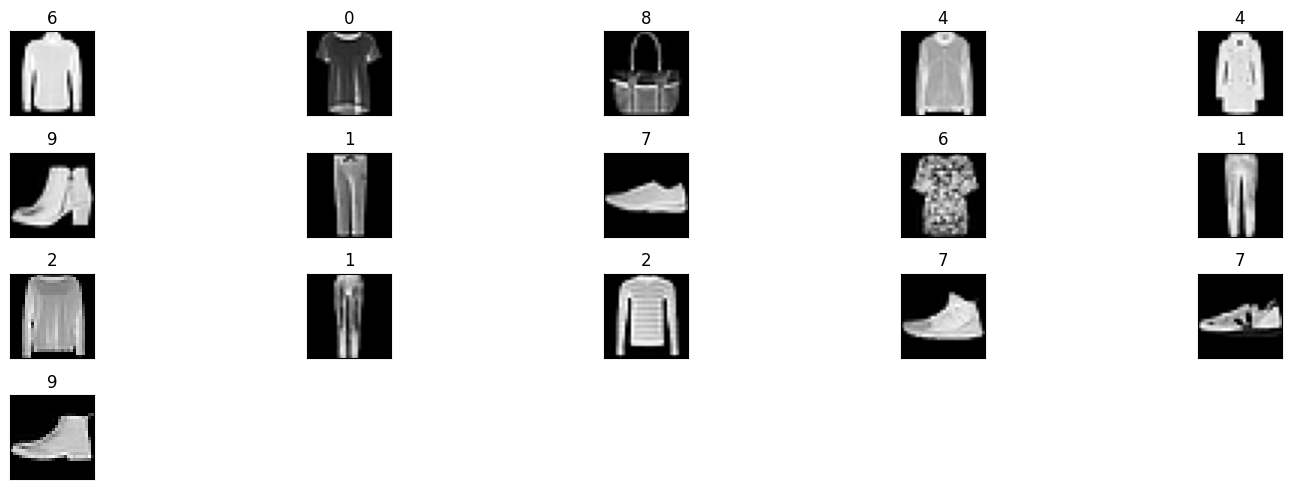

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

# Get a batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Visualize the first 16 images in the batch
fig = plt.figure(figsize=(15,5))
for idx in np.arange(16):
    ax = fig.add_subplot(4, 5, idx+1, xticks=[], yticks=[])
    # Display image (remove channel dimension for grayscale plot)
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # Set class label as title
    ax.set_title(labels[idx].item())
    fig.tight_layout()

#### Option 2: A CustomDatasetClass is defined

#### Download Fashion MNIST CSV files

In [46]:
# Create a local directory to store CSV data
!mkdir -p F_MNIST_data/FashionMNIST/csv/

# Attempt to download FashionMNIST CSV files (Note: URLs might be deprecated)
!wget -P F_MNIST_data/FashionMNIST/csv/ https://raw.githubusercontent.com/dragan-panov/fashion-mnist-csv/master/fashion-mnist_train.csv
!wget -P F_MNIST_data/FashionMNIST/csv/ https://raw.githubusercontent.com/dragan-panov/fashion-mnist-csv/master/fashion-mnist_test.csv

--2026-04-09 16:07:48--  https://raw.githubusercontent.com/dragan-panov/fashion-mnist-csv/master/fashion-mnist_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-09 16:07:48 ERROR 404: Not Found.

--2026-04-09 16:07:48--  https://raw.githubusercontent.com/dragan-panov/fashion-mnist-csv/master/fashion-mnist_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-09 16:07:48 ERROR 404: Not Found.



In [47]:
import torchvision
import pandas as pd
import os

# Ensure the target directory exists
path = os.path.expanduser("~/F_MNIST_data/FashionMNIST/csv/")
os.makedirs(path, exist_ok=True)

# Download dataset using torchvision tools
train_data = torchvision.datasets.FashionMNIST(root='./temp', train=True, download=True)
test_data = torchvision.datasets.FashionMNIST(root='./temp', train=False, download=True)

# Helper function to convert the binary dataset to CSV format for local file manipulation
def save_as_csv(dataset, filename):
    # Flatten 28x28 images to 784 pixel columns
    df = pd.DataFrame(dataset.data.numpy().reshape(-1, 784))
    # Insert labels as the first column
    df.insert(0, 'label', dataset.targets.numpy())
    df.to_csv(os.path.join(path, filename), index=False)
    print(f"Saved: {filename}")

save_as_csv(train_data, "fashion-mnist_train.csv")
save_as_csv(test_data, "fashion-mnist_test.csv")

Saved: fashion-mnist_train.csv
Saved: fashion-mnist_test.csv


In [48]:
import pandas as pd
# Read the newly created CSV files into Pandas DataFrames
train_csv = pd.read_csv("~/F_MNIST_data/FashionMNIST/csv/fashion-mnist_train.csv")
test_csv = pd.read_csv("~/F_MNIST_data/FashionMNIST/csv/fashion-mnist_test.csv")

print(f"Train size: {len(train_csv)}, Test size: {len(test_csv)}")

# Custom Dataset class to handle data from a Pandas DataFrame
class FashionDataset(Dataset):
    def __init__(self, data, transform=None):
        # Convert dataframe values to a list
        self.fashion_MNIST = list(data.values)
        self.transform = transform
        label = []
        image = []
        for i in self.fashion_MNIST:
            # label is in the first column, pixels in the rest
            label.append(i[0])
            image.append(i[1:])
        self.labels = np.asarray(label)
        # Reshape flat pixels back to (H, W, C) for transform compatibility
        self.images = np.asarray(image).reshape(-1, 28, 28, 1).astype('float32')

    def __getitem__(self, index):
        label = self.labels[index]
        image = self.images[index]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.images)

# Initialize the custom datasets
train_set = FashionDataset(train_csv, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]))
test_set = FashionDataset(test_csv, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]))

# Split train set into training and validation sets
train_dataset, valid_dataset = torch.utils.data.random_split(train_set, (50000, 10000))
print(f"Split sizes: {len(train_dataset)}, {len(valid_dataset)}, {len(test_set)}")

Train size: 60000, Test size: 10000
Split sizes: 50000, 10000, 10000


## Task 1: Compute other metrics, plot the confusion matrix apart from Accuracy

In [49]:
# Function to calculate classification accuracy for a given network and loader
def accuracy(network, dataloader):
    # Set model to evaluation mode (disables dropout/batchnorm)
    network.eval()
    total_correct = 0
    total_instances = 0
    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images, labels = images.to(device), labels.to(device)
            # Get index of the max log-probability as prediction
            predictions = torch.argmax(network(images), dim=1)
            total_correct += (predictions == labels).sum().item()
            total_instances += len(images)
    return round(total_correct / total_instances, 3)

## Task 2: Use Tensorboard to track your metrics live. Experiment with other tools, e.g. Weights and Biases (Free version, https://wandb.ai/site/pricing/)

In [50]:
# Import training utilities
!pip install tensorboard
from torch.autograd import Variable
from tqdm import tqdm
import os
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

# Initialize Tensorboard writer
writer = SummaryWriter()

# Define optimizer and learning rate
learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 1
log_dict = {
    'training_loss_per_batch': [],
    'validation_loss_per_batch': [],
    'training_accuracy_per_epoch': [],
    'validation_accuracy_per_epoch': []
}

# Main training loop
for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    train_losses = []
    model.train() # Set to training mode

    # Iterate over training batches
    for images, labels in tqdm(trainloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad() # Clear previous gradients
        predictions = model(images) # Forward pass
        loss = criterion_multi_class(predictions, labels) # Calculate loss

        log_dict['training_loss_per_batch'].append(loss.item())
        train_losses.append(loss.item())

        loss.backward() # Backward pass
        optimizer.step() # Update weights

    # Calculate metrics after epoch
    train_accuracy = accuracy(model, trainloader)
    log_dict['training_accuracy_per_epoch'].append(train_accuracy)

    # Validation phase
    val_losses = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(validloader):
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            val_loss = criterion_multi_class(predictions, labels)
            val_losses.append(val_loss.item())

        val_accuracy = accuracy(model, validloader)
        log_dict['validation_accuracy_per_epoch'].append(val_accuracy)

    # Log mean losses to Tensorboard
    train_mean = np.mean(train_losses)
    val_mean = np.mean(val_losses)
    writer.add_scalar("Loss/train", train_mean, epoch)

    print(f'Train Loss: {round(train_mean, 4)} | Train Acc: {train_accuracy} | Val Loss: {round(val_mean, 4)} | Val Acc: {val_accuracy}')

# Save the model state
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
torch.save(model.state_dict(), f'model_Shallow_FMNIST_{current_time}.pth')
print('Model saved.')
writer.close()

Epoch 1/1


100%|██████████| 750/750 [00:02<00:00, 267.29it/s]

Train Loss: 1.7365 | Train Acc: 0.673 | Val Loss: 1.0643 | Val Acc: 0.678
Model saved.


## Task 3: a) Experiment with different architectures and hyperparameters for the network above. b) Use the original image sizes from Fashion MNIST and change your transforms and layers appropriately.

In [51]:
# Define an experimental deeper neural network
class ExperimentalNN(nn.Module):
    def __init__(self, input_num, hidden_1, hidden_2, hidden_3, output_num):
        super(ExperimentalNN, self).__init__()
        self.flatten = nn.Flatten()
        # Deeper architecture with 3 hidden layers and Dropout for regularization
        self.fc1 = nn.Linear(input_num, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, hidden_3)
        self.output = nn.Linear(hidden_3, output_num)
        self.dropout = nn.Dropout(0.2) # 20% dropout probability
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        out = self.output(x)
        return out

# Define hyperparameters for the experimental model
input_size = 784
h1, h2, h3 = 256, 128, 64
output_size = 10

# Initialize and summarize the experimental model
exp_model = ExperimentalNN(input_size, h1, h2, h3, output_size).to(device)
print("Experimental Model Summary:")
summary(exp_model, (1, 28, 28))

Experimental Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
           Dropout-4                  [-1, 256]               0
            Linear-5                  [-1, 128]          32,896
              ReLU-6                  [-1, 128]               0
            Linear-7                   [-1, 64]           8,256
              ReLU-8                   [-1, 64]               0
            Linear-9                   [-1, 10]             650
Total params: 242,762
Trainable params: 242,762
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.93
Estimated Total Size (MB): 0.94
---------------